# Time Series Analisys on Geoespatial Data with Python


Author: João Otavio Nascimento Firigato

email: joaootavionf007@gmail.com

LinkedIn: https://www.linkedin.com/in/jo%C3%A3o-otavio-firigato-4876b3aa/


## First instructions:

✅ Access the link to join our private WhatsApp community for students: https://chat.whatsapp.com/EPn27ZgR07lF3e1vnj8FiI


❗ It is important to access the Whatsapp Group to get the Colab Notebooks, as the PDF files are protected from text copying.




# Chapter 10 - Time Series Forecast - Part 3

# Machine Learning Models

While most of the machine learning algorithms available in scikit-learn (and several other compatible libraries, such as LightGBM) are commonly used for regression and tabular classification, there is no inherent reason why they cannot be effectively applied to time series forecasting.

From a theoretical perspective, these approaches may not necessarily satisfy the conditions required for a regression model. Time series data typically exhibit some degree of autocorrelation, meaning that data observed at time t is related to previous data (t-1) and possibly even more. A typical regression model typically assumes independent observations, so they may not be well suited to capture autocorrelation. However, it is still possible to use lagged series as predictors and allow the model to learn from existing autocorrelation or other patterns.

Scikit-learn offers a wide range of regression models, ranging from basic linear regression to highly advanced boosted trees. Along with this, hyperparameter tuning and implementing cross-validation are common practices to ensure better model generality and accuracy.

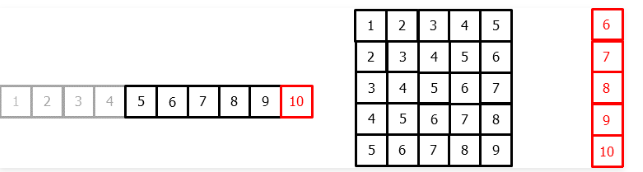

Since we are treating time series forecasting as a regression problem, we would need to have a predictor. Here, we assume that we only have a univariate series with 5 days

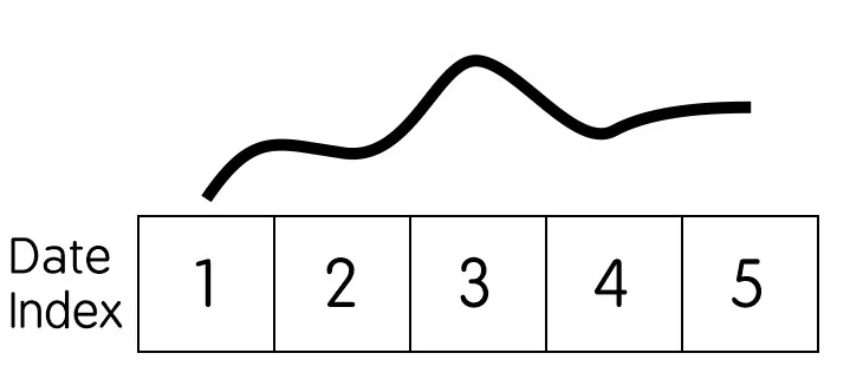

At the beginning, we only have data up to day 5. Let’s say we use the previous 3 days as the predictor. This means we are using up to 3 lagged data. To predict day 4, we use data from days 1 to 3. To predict day 5, we use data from days 2 to 4. Then, to predict day 6, we use data from days 3 to 5.

In tabular terms, we can write the predictor and the response as follows. We label yesterday’s data as Xt-1, two days ago as Xt-2, and three days ago as Xt-3.

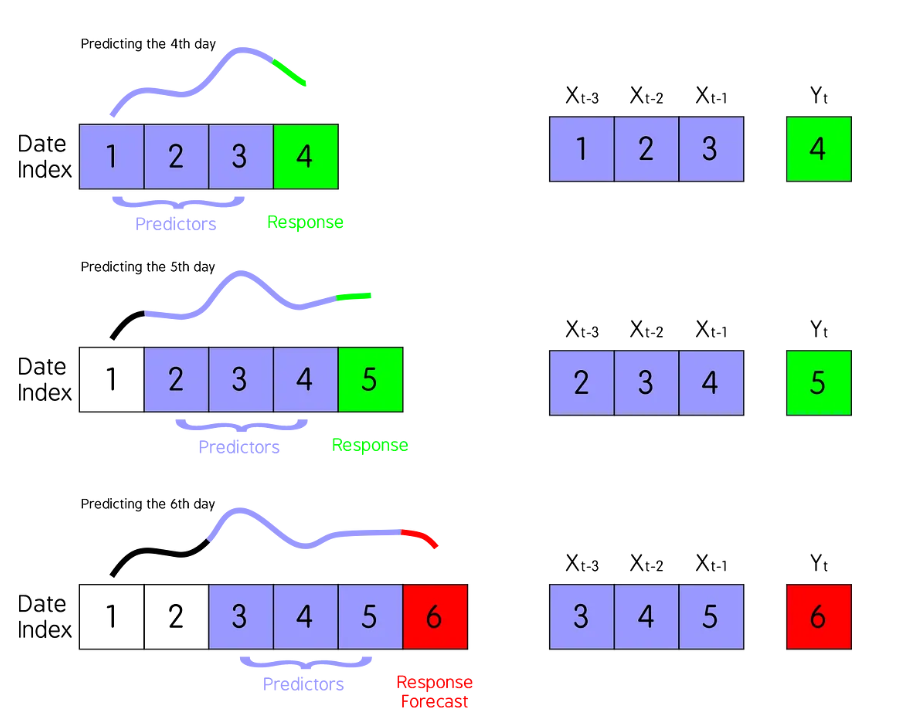

We have established a way to predict one step into the future. How about predicting 2 days ahead? Or 3? This is where we introduce the concept of recursive prediction. In short, to predict day 7, we make a prediction for day 6 and then use that predicted value as our Xt-1. Essentially, we are treating the previous prediction as a new predictor for the future. We do this as often as necessary and it is quite efficient.

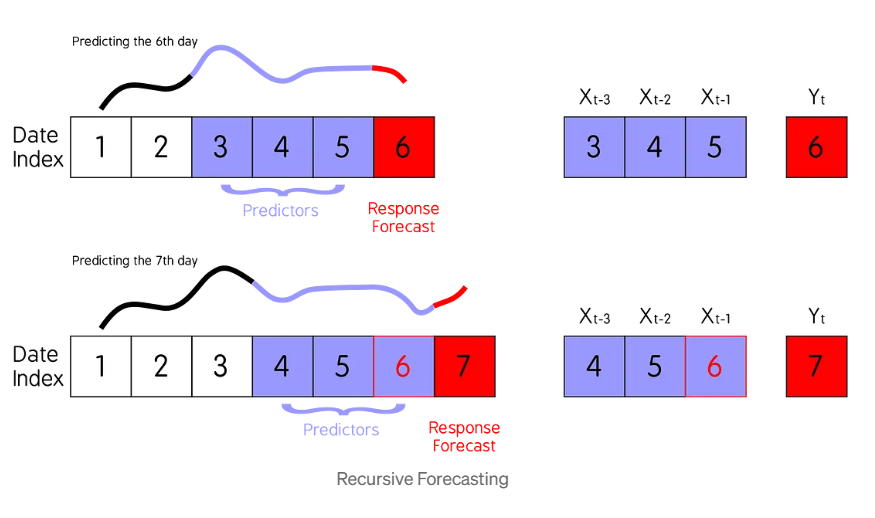

However, there are several problems with this approach. If we want to predict far into the future, the model may give a relatively flat prediction. It may also introduce new bias, as the 6th predicted data may be far from the actual value.

Again, it is possible to include exogenous variables in the model. Keep in mind that to predict the 6th data, we must also provide the exogenous variable for that same index.

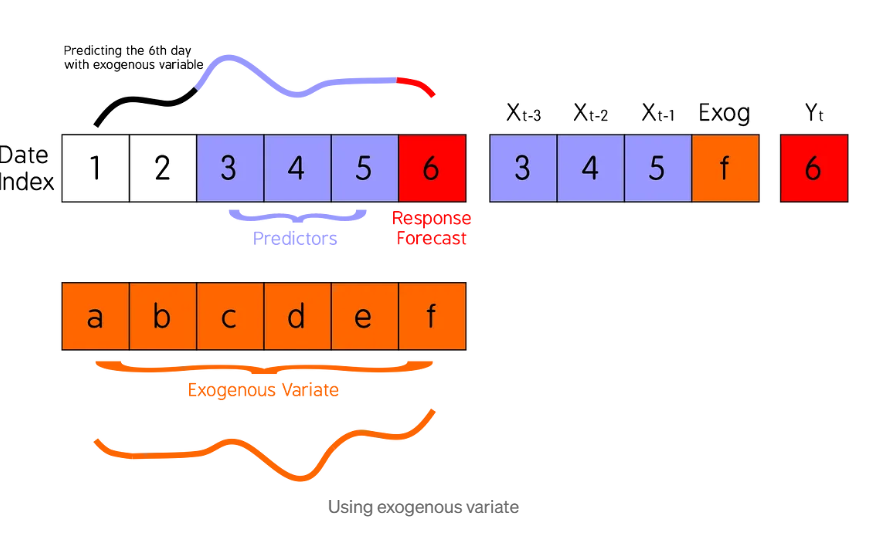

Let's get some time series data. Let's use Sentinel 5P data in this example:

In [ ]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import datetime

In [ ]:
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

We select an area of ​​analysis:

In [ ]:
italy = ee.Geometry.Polygon([[[8.290016551188252, 45.79137351065613],
          [8.290016551188252, 45.0588767633071],
          [10.168678660563252, 45.0588767633071],
          [10.168678660563252, 45.79137351065613]]])

The start and end date:

In [ ]:
startDate = '2023-01-01'
endDate = '2023-12-31'

Then we will get our collection of NO2 images:

In [ ]:
s5p_no = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2').filterDate(startDate, endDate).filterBounds(italy).select('NO2_column_number_density')

Let's now extract the time series and convert it into a dataframe:

In [ ]:
def extract_time_series(image_collection, column):
  def reduce_region_func(image):
    reduced_image = image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=italy,
        scale=1113,
        maxPixels=1e13
    )
    return image.set(reduced_image)

  reduced_collection = image_collection.map(reduce_region_func)

  time_series_time = reduced_collection.aggregate_array('system:time_start').getInfo()
  time_series_values = reduced_collection.aggregate_array(column).getInfo()

  # Create a DataFrame
  time_series_df = pd.DataFrame({'time_start': time_series_time, 'value': time_series_values})
  time_series_df['time_start'] = pd.to_datetime(time_series_df['time_start'], unit='ms')
  time_series_df.set_index('time_start', inplace=True)
  return time_series_df

no2_time_series = extract_time_series(s5p_no,'NO2_column_number_density' )

In [ ]:
no2_time_series.index = no2_time_series.index.strftime('%Y-%m-%d')

In [ ]:
no2_time_series_grouped = no2_time_series.groupby(no2_time_series.index).sum()

In [ ]:
df = pd.DataFrame(columns=['NO2'])
df['NO2'] = no2_time_series_grouped['value']

In [ ]:
df.dropna(axis=0, inplace=True)

Thus, we have our time series of the sum of NO2 in our region of interest:

In [ ]:
df

,NO2
time_start,
2023-01-01,0.000000
2023-01-02,0.000000
2023-01-03,0.000000
2023-01-04,0.611969
2023-01-05,2.356767
...,...
2023-12-26,0.148370
2023-12-27,0.389392
2023-12-28,0.013645


We will transform our time series into a dataframe adjusted for the classification task by applying shift:

In [ ]:
df['NO2_shift1'] = df['NO2'].shift(1)
df['NO2_shift2'] = df['NO2'].shift(2)
df['NO2_shift3'] = df['NO2'].shift(3)
df['NO2_shift4'] = df['NO2'].shift(4)
df['NO2_shift5'] = df['NO2'].shift(5)
df['NO2_shift6'] = df['NO2'].shift(6)
df['NO2_shift7'] = df['NO2'].shift(7)

We will remove the days where we do not have all the full shifts:

In [ ]:
df.dropna(axis=0, inplace=True)

So our DataFrame is ready:

In [ ]:
df

,NO2,NO2_shift1,NO2_shift2,NO2_shift3,NO2_shift4,NO2_shift5,NO2_shift6,NO2_shift7
time_start,,,,,,,,
2023-01-08,0.000000,0.133376,0.244905,2.356767,0.611969,0.000000,0.000000,0.000000
2023-01-09,1.812042,0.000000,0.133376,0.244905,2.356767,0.611969,0.000000,0.000000
2023-01-10,1.831945,1.812042,0.000000,0.133376,0.244905,2.356767,0.611969,0.000000
2023-01-11,0.048411,1.831945,1.812042,0.000000,0.133376,0.244905,2.356767,0.611969
2023-01-12,3.785621,0.048411,1.831945,1.812042,0.000000,0.133376,0.244905,2.356767
...,...,...,...,...,...,...,...,...
2023-12-26,0.148370,3.243424,2.299797,1.327712,0.956265,1.357426,3.494729,4.523318
2023-12-27,0.389392,0.148370,3.243424,2.299797,1.327712,0.956265,1.357426,3.494729
2023-12-28,0.013645,0.389392,0.148370,3.243424,2.299797,1.327712,0.956265,1.357426


From the Shift columns we will predict the next value which is our target column NO2:

In [ ]:
X = df[['NO2', 'NO2_shift1', 'NO2_shift2', 'NO2_shift3', 'NO2_shift4', 'NO2_shift5', 'NO2_shift6']]

y = df['NO2_shift7']

We split the data into training and testing:

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=False)

And here we will use the Decision Tree Regressor:

In [ ]:
from sklearn.tree import DecisionTreeRegressor
classifier = DecisionTreeRegressor(random_state=42)
classifier.fit(X_train, y_train)

from sklearn.metrics import r2_score
print(r2_score(list(y_test), list(classifier.predict(X_test))))

-0.9301139049419489


In [ ]:
from sklearn.model_selection import GridSearchCV

my_dt = GridSearchCV(DecisionTreeRegressor(random_state=44),
                 {'min_samples_split': list(range(20,50, 2)),
                 'max_features': [0.6, 0.7, 0.8, 0.9, 1.]},
                scoring = 'r2', n_jobs = -1)

my_dt.fit(X_train, y_train)
print(r2_score(list(y_test), list(my_dt.predict(X_test))))

0.040874925952024244


We can check the predicted data compared to the actual data:

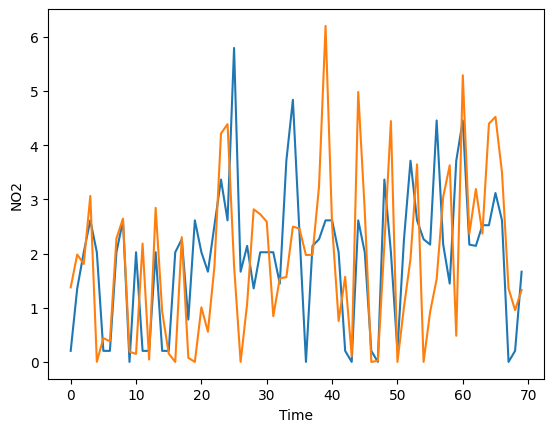

In [ ]:
fcst = my_dt.predict(X_test)

plt.plot(list(fcst))
plt.plot(list(y_test))
plt.ylabel('NO2')
plt.xlabel('Time')
plt.show()

## Recursive multi-step forecasting

Let's now use recursive multistep forecasting. To do this, we will select a point and obtain LST time series data:

In [ ]:
geometry_test = ee.Geometry.Point([-55.05744298464864, -13.547299531642683])

In [ ]:
startDate = '2016-01-01'
endDate = '2024-12-31'

We generate our image collection according to geographic point and start and end dates:

In [ ]:
modisLst = ee.ImageCollection('MODIS/061/MOD11A1').filterDate(startDate, endDate).filterBounds(geometry_test).select('LST_Day_1km')

Let's get the monthly average between 2016 and 2024:

In [ ]:
months = ee.List.sequence(1,12)
years = ee.List.sequence(2016, 2024)

In [ ]:
def monthly(collection):
  img_coll = ee.ImageCollection([])
  for y in years.getInfo():
    for m in months.getInfo():
      filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
      filtered = filtered.median()
      img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).getInfo()['value']))
  return img_coll

In [ ]:
modisLst = monthly(modisLst)

In [ ]:
def meanLST(image):
    image = ee.Image(image)
    meanDict = image.reduceRegion(reducer = ee.Reducer.mean().setOutputs(['LST_Day_1km']),
        geometry = geometry_test,
        scale = image.projection().nominalScale().getInfo(),
                                    maxPixels = 1e13,
                                    bestEffort = True);
    return meanDict.get('LST_Day_1km').getInfo()

In [ ]:
listOfImages_modis = modisLst.select('LST_Day_1km').toList(modisLst.size())

lst_coll = []

for i in range(listOfImages_modis.length().getInfo()):
    image = ee.Image(listOfImages_modis.get(i-1))
    temp_lst = meanLST(image)
    lst_coll.append(temp_lst)

After extracting we convert it into a DataFrame:

In [ ]:
dates = np.array(modisLst.aggregate_array("system:time_start").getInfo())
day = [datetime.datetime.fromtimestamp(i/1000).strftime('%Y-%m-%d') for i in (dates)]

In [ ]:
lst_df = pd.DataFrame(lst_coll, index = day, columns = ['LST'])
lst_df.index = pd.to_datetime(lst_df.index)
lst_df.sort_index(ascending = True, inplace = True)

In [ ]:
lst_df

,LST
2016-01-01,15035.0
2016-02-01,14998.0
2016-03-01,15168.0
2016-04-01,15132.0
2016-05-01,15227.0
...,...
2024-08-01,15135.0
2024-09-01,15318.0
2024-10-01,15426.0
2024-11-01,15388.5


We present the time series:

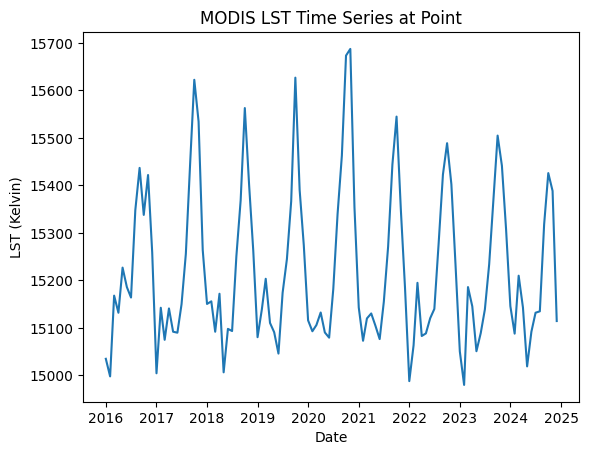

In [ ]:
plt.plot(lst_df['LST'])
plt.xlabel('Date')
plt.ylabel('LST (Kelvin)')
plt.title('MODIS LST Time Series at Point')
plt.show()

We divide it into training and testing:

In [ ]:
steps = 24
data_train = lst_df[:-steps]
data_test  = lst_df[-steps:]

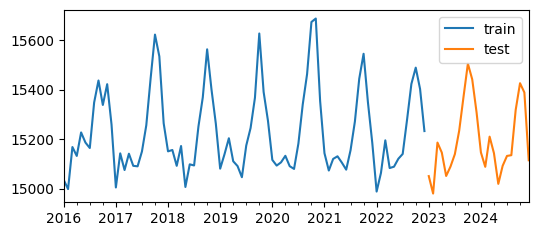

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
ax.legend();

Let's use the skforest implementation:

In [ ]:
!pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.0/815.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 16.7 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.plot import plot_prediction_intervals
from sklearn.linear_model import Ridge

In [ ]:
forecaster = ForecasterRecursive(
                 regressor = RandomForestRegressor(random_state=123),
                 lags      = 12
             )
forecaster.fit(y=data_train['LST'])
forecaster

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ Series has a pandas DatetimeIndex without a frequency. The index will be replaced by │
│ a RangeIndex starting from 0 with a step of 1. To avoid this warning, set the        │
│ frequency of the DatetimeIndex using `y = y.asfreq('desired_frequency',              │
│ fill_value=np.nan)`.                                                                 │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1411    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12] 
Window features: None 
Window size: 12 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 83] 
Training index type: RangeIndex 
Training index frequency: 1 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-03-28 15:14:32 
Last fit date: 2025-03-28 15:14:32 
Skforecast version: 0.15.1 
Python version: 3.11.11 
Forecaster id: None

We can apply the prediction 24 steps into the future:

In [ ]:
steps = 24
predictions = forecaster.predict(steps=steps)

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ `last_window` has a pandas DatetimeIndex without a frequency. The index will be      │
│ replaced by a RangeIndex starting from 0 with a step of 1. To avoid this warning,    │
│ set the frequency of the DatetimeIndex using `last_window =                          │
│ last_window.asfreq('desired_frequency', fill_value=np.nan)`.                         │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1455    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
predictions.index = data_test.index

Then we compare the predicted and test values:

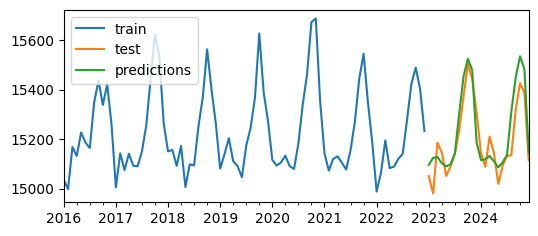

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

In [ ]:
error_mse = mean_squared_error(
                y_true = data_test['LST'],
                y_pred = predictions
            )
print(f"Test error (MSE): {error_mse}")

Test error (MSE): 5892.410045833322


In [ ]:
importance = forecaster.get_feature_importances()
importance.head(10)

,feature,importance
11,lag_12,0.802108
3,lag_4,0.029228
0,lag_1,0.027335
8,lag_9,0.026142
4,lag_5,0.024027
10,lag_11,0.019620
5,lag_6,0.018887
7,lag_8,0.017335
9,lag_10,0.010976
6,lag_7,0.009295


## Probabilistic forecasting

Probabilistic forecasting, as opposed to point forecasting, is a family of techniques that allows the prediction of the expected distribution of the outcome rather than a single future value. This type of forecasting provides much richer information because it allows the creation of prediction intervals, the range of likely values ​​where the true value might fall. More formally, a prediction interval defines the range within which the true value of the response variable is expected to be found with a given probability.

In [ ]:
forecaster = ForecasterRecursive(
                 regressor = Ridge(alpha=0.1, random_state=765),
                 lags      = 12
             )
forecaster.fit(y=data_train['LST'], store_in_sample_residuals=True)

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ Series has a pandas DatetimeIndex without a frequency. The index will be replaced by │
│ a RangeIndex starting from 0 with a step of 1. To avoid this warning, set the        │
│ frequency of the DatetimeIndex using `y = y.asfreq('desired_frequency',              │
│ fill_value=np.nan)`.                                                                 │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1411    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
predictions = forecaster.predict_interval(
                steps    = steps,
                interval = [5, 95],
                method   = 'bootstrapping',
                n_boot   = 500
              )

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ `last_window` has a pandas DatetimeIndex without a frequency. The index will be      │
│ replaced by a RangeIndex starting from 0 with a step of 1. To avoid this warning,    │
│ set the frequency of the DatetimeIndex using `last_window =                          │
│ last_window.asfreq('desired_frequency', fill_value=np.nan)`.                         │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1455    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────── IndexWarning ────────────────────────────────────╮
│ `last_window` has a pandas DatetimeIndex without a frequency. The index will be      │
│ replaced by a RangeIndex starting from 0 with a step of 1. To avoid this warning,    │
│ set the frequency of the DatetimeIndex using `last_window =                          │
│ last_window.asfreq('desired_frequency', fill_value=np.nan)`.                         │
│                                                                                      │
│ Category : IndexWarning                                                              │
│ Location : /usr/local/lib/python3.11/dist-packages/skforecast/utils/utils.py:1455    │
│ Suppress : warnings.simplefilter('ignore', category=IndexWarning)                    │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
predictions.index = data_test.index

We obtain the predictions and the lower and upper bounds:

In [ ]:
predictions

,pred,lower_bound,upper_bound
2023-01-01,15109.370584,14993.803688,15182.299833
2023-02-01,15124.248798,15065.542411,15215.041477
2023-03-01,15133.052543,15014.965621,15195.294893
2023-04-01,15128.439272,15000.971818,15196.639739
2023-05-01,15113.279702,15005.450686,15187.140760
2023-06-01,15098.032501,14997.979767,15178.710010
2023-07-01,15152.621431,15075.536143,15220.744993
2023-08-01,15282.585015,15186.972088,15365.500965
2023-09-01,15422.720289,15338.270998,15510.739895
2023-10-01,15472.790271,15367.630714,15693.779511


In [ ]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

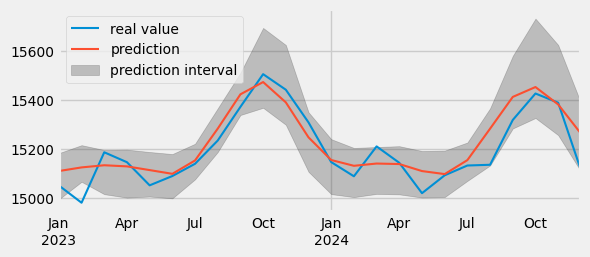

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2.5))
plot_prediction_intervals(
    predictions     = predictions,
    y_true          = data_test,
    target_variable = "LST",
    ax              = ax
)

## Forecasting with exogenous variables

We can add exogenous variables to the model. Let's use the month index as an exogenous variable:

In [ ]:
lst_df['month'] = lst_df.index.month

In [ ]:
lst_df

,LST,month
2016-01-01,15035.0,1
2016-02-01,14998.0,2
2016-03-01,15168.0,3
2016-04-01,15132.0,4
2016-05-01,15227.0,5
...,...,...
2024-08-01,15135.0,8
2024-09-01,15318.0,9
2024-10-01,15426.0,10
2024-11-01,15388.5,11


In [ ]:
lst_df.index = pd.to_datetime(lst_df.index)
lst_df.index.freq = 'MS'

In [ ]:
steps = 24
data_train = lst_df[:-steps]
data_test  = lst_df[-steps:]

We will use XGBRegressor as the algorithm to be used in recursive prediction:

In [ ]:
from xgboost import XGBRegressor

In [ ]:
forecaster = ForecasterRecursive(
                 regressor = XGBRegressor(random_state=42),
                 lags      = 12
             )
forecaster.fit(y=data_train['LST'], exog=data_train['month'])

In [ ]:
predictions = forecaster.predict(steps=steps, exog=data_test['month'])

We generate the results and compare them with the reference data:

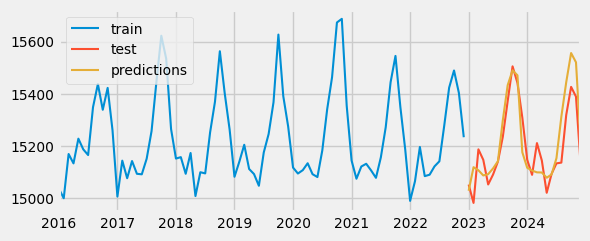

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

## Prophet

Prophet is an open-source tool released by Facebook's Data Science team that produces time-series forecasting data based on an additive model where a non-linear trend adjusts for seasonality and holiday effects. The design principles allow parameter adjustments without much knowledge of the underlying model, making the method applicable to teams with less statistical expertise.


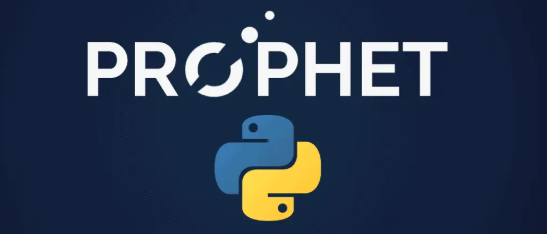

Prophet is designed to forecast univariate time series data based on decomposition components (trend+seasonality+holidays). Prophet is easy to use and automatically finds a good set of hyperparameters in an effort to make skillful predictions for trending data without requiring special domain knowledge.

Prophet also provides easy and customizable ways to tune the hyperparameters, even for someone who has no experience in forecasting models to make skillful predictions for a variety of problems in a business scenario.

Prophet is particularly well-suited for business forecasting applications and has gained popularity due to its ease of use and effectiveness in handling a wide range of time series data. As with all tools, keep in mind that while Prophet is powerful, the choice of forecasting method depends on the specific characteristics of the data and the goals of the analysis. In general, Prophet is not guaranteed to perform better than other models. However, Prophet does come with some useful features, for example, reflecting pre- and post-COVID seasonality changes or treating lockdowns as one-off holidays.

In [ ]:
!pip install prophet

We create the columns 'ds' and 'y':

In [ ]:
train_prophet = pd.DataFrame()
train_prophet['ds'] = data_train.index
train_prophet['y'] = data_train.LST.values

We can apply Prophet to our dataset:

In [ ]:
from prophet import Prophet


model = Prophet( yearly_seasonality=True, seasonality_mode = 'additive')
model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9ebnlkdx/jedv4oec.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9ebnlkdx/jgsp0py5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=47993', 'data', 'file=/tmp/tmp9ebnlkdx/jedv4oec.json', 'init=/tmp/tmp9ebnlkdx/jgsp0py5.json', 'output', 'file=/tmp/tmp9ebnlkdx/prophet_modelx_dtpwel/prophet_model-20250523005614.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
00:56:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:56:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods = 24, freq = 'M')

/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [ ]:
future

,ds
0,2016-01-01
1,2016-02-01
2,2016-03-01
3,2016-04-01
4,2016-05-01
...,...
103,2024-07-31
104,2024-08-31
105,2024-09-30
106,2024-10-31


We apply prediction to generate future data:

In [ ]:
forecast = model.predict(future)

In [ ]:
forecast.index = lst_df.index

In [ ]:
forecast.iloc[-24:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
2023-01-01,2022-12-31,15087.575398,15028.129569,15145.838750
2023-02-01,2023-01-31,14998.490457,14942.658680,15057.143660
2023-03-01,2023-02-28,15251.216540,15195.016855,15309.554991
2023-04-01,2023-03-31,15103.989810,15044.341049,15162.383139
2023-05-01,2023-04-30,14955.641776,14893.764485,15018.697603
2023-06-01,2023-05-31,15054.463797,14993.486580,15118.273605
2023-07-01,2023-06-30,15176.739494,15108.195946,15238.086212
2023-08-01,2023-07-31,15186.660825,15115.538625,15258.944642
2023-09-01,2023-08-31,15353.880081,15278.573998,15429.496362
2023-10-01,2023-09-30,15774.148481,15688.782219,15856.575931


Let's compare with the reference values:

In [ ]:
from sklearn.metrics import r2_score
print(r2_score(list(data_test['LST']), list(forecast.iloc[-24:]['yhat'])))

0.4705484740015937


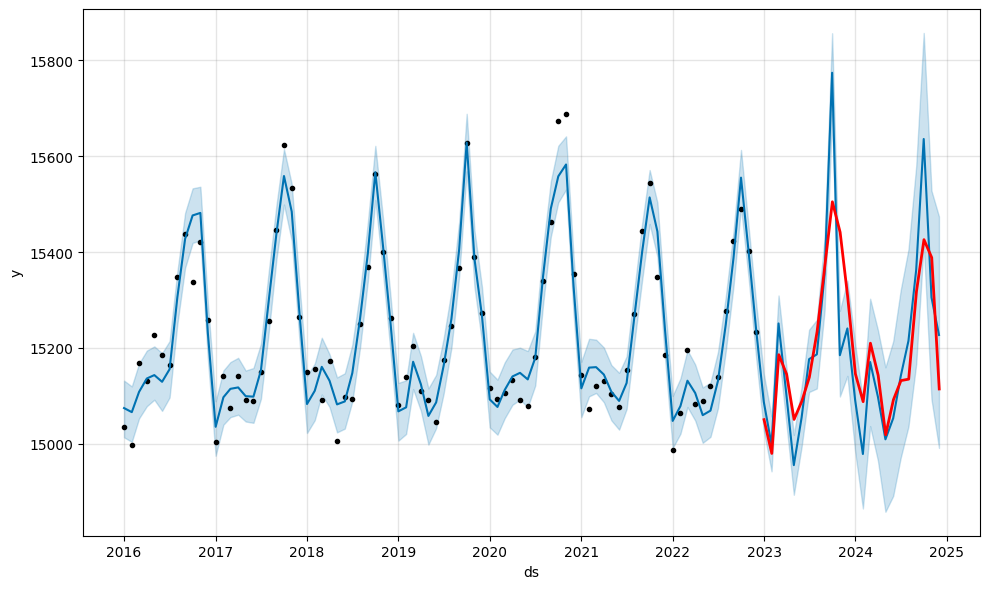

In [ ]:
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(data_test['LST'], label='Valid', color = 'red', linewidth = 2)

plt.show()

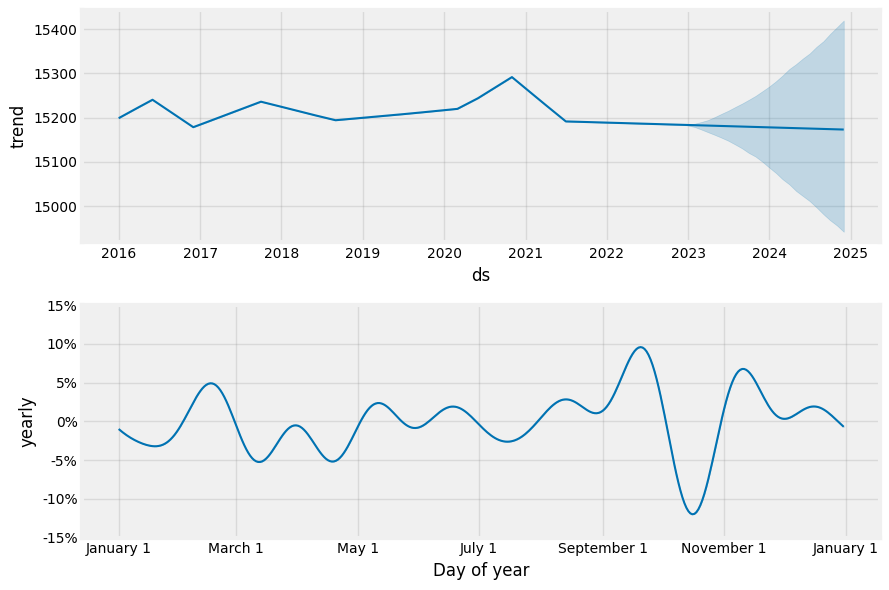

In [ ]:
model.plot_components(forecast);

## Thank you! See you in the next Chapter!

References:

https://medium.com/@mouse3mic3/a-practical-guide-on-scikit-learn-for-time-series-forecasting-bbd15b611a5d

https://github.com/ashishpatel26/Introduction-to-Time-Series-forecasting/blob/master/Time%20Series%20in%20Python.ipynb

https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn